In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('06-study_hours_grades.csv')

In [3]:
df['grade'].values

array([30.2039391 , 57.87845188, 46.36840053, 39.33071682, 14.84388804,
       16.3600376 , 11.98290307, 55.42305174, 40.74298717, 41.87754858,
       11.67739265, 57.72532805, 50.26828804, 21.84030811, 21.15324741,
       21.03278573, 23.5336771 , 35.61939683, 32.25977779, 26.51254726,
       39.63429626, 16.60337508, 22.39456248, 25.92567892, 34.42855086,
       51.97127813, 19.83966886, 37.71878772, 40.34400049, 11.03228113,
       41.10003381, 21.60227932, 13.18092757, 60.57356417, 53.04211145,
       52.06367241, 25.4047826 , 14.285591  , 44.39517288, 28.03248686,
       15.66256797, 35.47307065, 14.67521415, 54.42947967, 21.32201187,
       42.12260013, 27.41635804, 36.66090328, 36.27599356, 20.26925764])

In [4]:
X= torch.tensor(df['study_hours'].values, dtype=torch.float32).unsqueeze(1)
Y= torch.tensor(df['grade'].values, dtype=torch.float32).unsqueeze(1)
# Pandas / NumPy varsayılan olarak float64 (Double) veri tipi kullanır. PyTorch modellerindeki katmanlar (nn.Linear gibi) ise varsayılan olarak
# float32 (Float) bekler. Bu yüzden dtype=torch.float32 belirterek tip uyuşmazlığının (RuntimeError: mat1 and mat2 must have the same dtype) 
# önüne geçmişsiniz.

# df['study_hours'].values ifadesi 1 boyutlu bir dizi döndürür (örneğin boyutu [40] şeklindedir). PyTorch katmanları ise 
# veriyi [Örnek Sayısı, Özellik Sayısı] yani [Batch Size, Num Features] şeklinde 2 boyutlu bir matris olarak bekler.
# .unsqueeze(1) kullanarak diziyi 2. boyuttan genişletmiş ve boyutunu [40, 1] yapmış olursunuz (40 örnek, 1 özellik). 
# Bu da RuntimeError: mat1 and mat2 shapes cannot be multiplied hatasını çözer.

In [5]:
X


tensor([[3.7454],
        [9.5071],
        [7.3199],
        [5.9866],
        [1.5602],
        [1.5599],
        [0.5808],
        [8.6618],
        [6.0111],
        [7.0807],
        [0.2058],
        [9.6991],
        [8.3244],
        [2.1234],
        [1.8182],
        [1.8340],
        [3.0424],
        [5.2476],
        [4.3195],
        [2.9123],
        [6.1185],
        [1.3949],
        [2.9214],
        [3.6636],
        [4.5607],
        [7.8518],
        [1.9967],
        [5.1423],
        [5.9241],
        [0.4645],
        [6.0754],
        [1.7052],
        [0.6505],
        [9.4889],
        [9.6563],
        [8.0840],
        [3.0461],
        [0.9767],
        [6.8423],
        [4.4015],
        [1.2204],
        [4.9518],
        [0.3439],
        [9.0932],
        [2.5878],
        [6.6252],
        [3.1171],
        [5.2007],
        [5.4671],
        [1.8485]])

In [6]:
train_split=int(0.8*len(X))

In [7]:
train_split

40

In [8]:
X_train, Y_train= X[:train_split],Y[:train_split]
X_test,Y_test=X[train_split:],Y[train_split:]

In [9]:
X_train,X_test

(tensor([[3.7454],
         [9.5071],
         [7.3199],
         [5.9866],
         [1.5602],
         [1.5599],
         [0.5808],
         [8.6618],
         [6.0111],
         [7.0807],
         [0.2058],
         [9.6991],
         [8.3244],
         [2.1234],
         [1.8182],
         [1.8340],
         [3.0424],
         [5.2476],
         [4.3195],
         [2.9123],
         [6.1185],
         [1.3949],
         [2.9214],
         [3.6636],
         [4.5607],
         [7.8518],
         [1.9967],
         [5.1423],
         [5.9241],
         [0.4645],
         [6.0754],
         [1.7052],
         [0.6505],
         [9.4889],
         [9.6563],
         [8.0840],
         [3.0461],
         [0.9767],
         [6.8423],
         [4.4015]]),
 tensor([[1.2204],
         [4.9518],
         [0.3439],
         [9.0932],
         [2.5878],
         [6.6252],
         [3.1171],
         [5.2007],
         [5.4671],
         [1.8485]]))

In [10]:
len(X_train),len(X_test)

(40, 10)

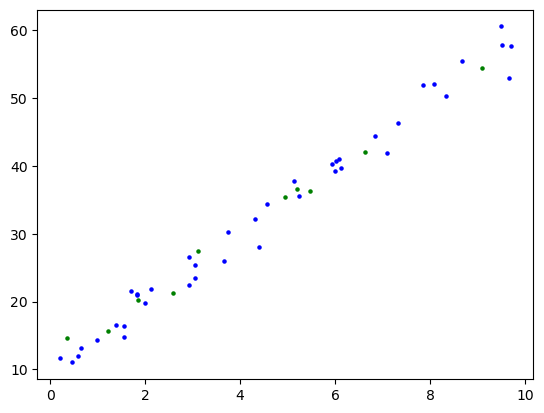

In [11]:

plt.scatter(X_train,Y_train,c='b',s=5,label='training data')
plt.scatter(X_test,Y_test,c='g',s=5,label='label test data')

plt.show()


In [12]:
import torch.nn as nn
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_layer=nn.Linear(in_features=1,out_features=1)
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

In [13]:
torch.manual_seed(42)
model=LinearRegressionModel()

In [14]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [15]:
loss_fn=nn.MSELoss()

optimizer=torch.optim.SGD(model.parameters(),lr=0.001)

In [16]:
epochs = 120

for epoch in range(epochs):
    model.train()
    y_pred = model(X_train)  # Modele tahmin yaptırılır
    loss = loss_fn(y_pred, Y_train) # Tahmin ile gerçek değer arasındaki kayıp hesaplanır
    optimizer.zero_grad() # Önceki adımdan kalan gradyanlar sıfırlanır

    loss.backward() # Kayıp üzerinden geriye doğru yayılım (backpropagation) yapılarak gradyanlar hesaplanır
    optimizer.step() # Hesaplanan gradyanlara göre modelin ağırlıkları step step güncellenir

    model.eval()
    with torch.inference_mode():
        test_pred = model(X_test)
        test_loss = loss_fn(test_pred, Y_test)

        if(epoch % 5 == 0):
            print(f"Epoch: {epoch}, Train loss: {loss}, Test loss: {test_loss}")
        

Epoch: 0, Train loss: 965.6339721679688, Test loss: 717.683349609375
Epoch: 5, Train loss: 530.086669921875, Test loss: 405.685546875
Epoch: 10, Train loss: 295.7361755371094, Test loss: 236.03225708007812
Epoch: 15, Train loss: 169.6184539794922, Test loss: 143.42544555664062
Epoch: 20, Train loss: 101.72415924072266, Test loss: 92.61089324951172
Epoch: 25, Train loss: 65.15110778808594, Test loss: 64.53108215332031
Epoch: 30, Train loss: 45.427330017089844, Test loss: 48.86598587036133
Epoch: 35, Train loss: 34.767799377441406, Test loss: 40.014488220214844
Epoch: 40, Train loss: 28.984630584716797, Test loss: 34.92718505859375
Epoch: 45, Train loss: 25.824926376342773, Test loss: 31.93711280822754
Epoch: 50, Train loss: 24.0767879486084, Test loss: 30.128173828125
Epoch: 55, Train loss: 23.088253021240234, Test loss: 28.993366241455078
Epoch: 60, Train loss: 22.508625030517578, Test loss: 28.2496337890625
Epoch: 65, Train loss: 22.14923667907715, Test loss: 27.737096786499023
Epoch:

In [17]:
model.eval()
with torch.inference_mode():
    y_preds= model(X_test)

In [18]:
y_preds

tensor([[ 9.8148],
        [32.9787],
        [ 4.3736],
        [58.6882],
        [18.3035],
        [43.3673],
        [21.5894],
        [34.5239],
        [36.1778],
        [13.7143]])

In [20]:
Y_test

tensor([[15.6626],
        [35.4731],
        [14.6752],
        [54.4295],
        [21.3220],
        [42.1226],
        [27.4164],
        [36.6609],
        [36.2760],
        [20.2693]])

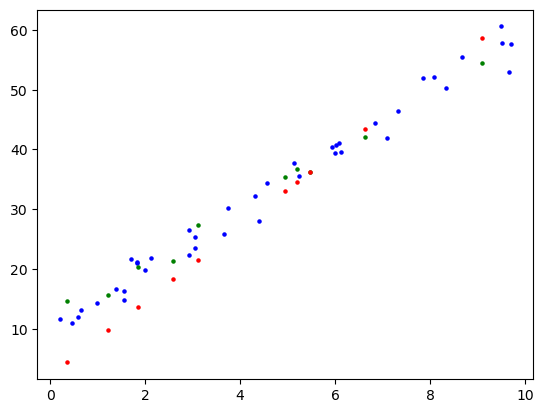

In [21]:
plt.scatter(X_train, Y_train,c='b',s=5,label='training data')
plt.scatter(X_test, Y_test,c='g',s=5,label='test data')
plt.scatter(X_test, y_preds,c='r',s=5,label='predictions')

plt.show()